In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")


Using device: cuda
GPU: Tesla P100-PCIE-16GB


In [2]:
# Find what's available under /kaggle/input
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/aptos2019-blindness-detection
/kaggle/input/competitions/aptos2019-blindness-detection/train_images
/kaggle/input/competitions/aptos2019-blindness-detection/test_images


Shape: (3662, 2)
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
5  0083ee8054ee          4
6  0097f532ac9f          0
7  00a8624548a9          2
8  00b74780d31d          2
9  00cb6555d108          1

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


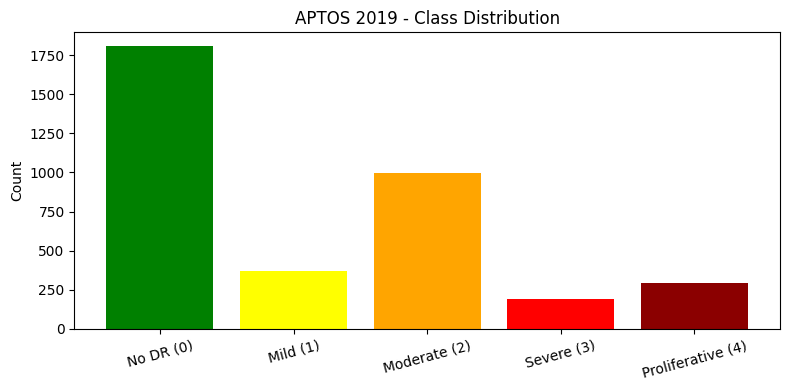

In [3]:
# Correct path
DATASET_PATH = "/kaggle/input/competitions/aptos2019-blindness-detection"

# Load CSV
train_df = pd.read_csv(f'{DATASET_PATH}/train.csv')

print(f"Shape: {train_df.shape}")
print(train_df.head(10))
print("\nClass distribution:")
print(train_df['diagnosis'].value_counts().sort_index())

# Visualize class distribution
plt.figure(figsize=(8,4))
labels = ['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']
counts = train_df['diagnosis'].value_counts().sort_index()
plt.bar(labels, counts.values, color=['green','yellow','orange','red','darkred'])
plt.title('APTOS 2019 - Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

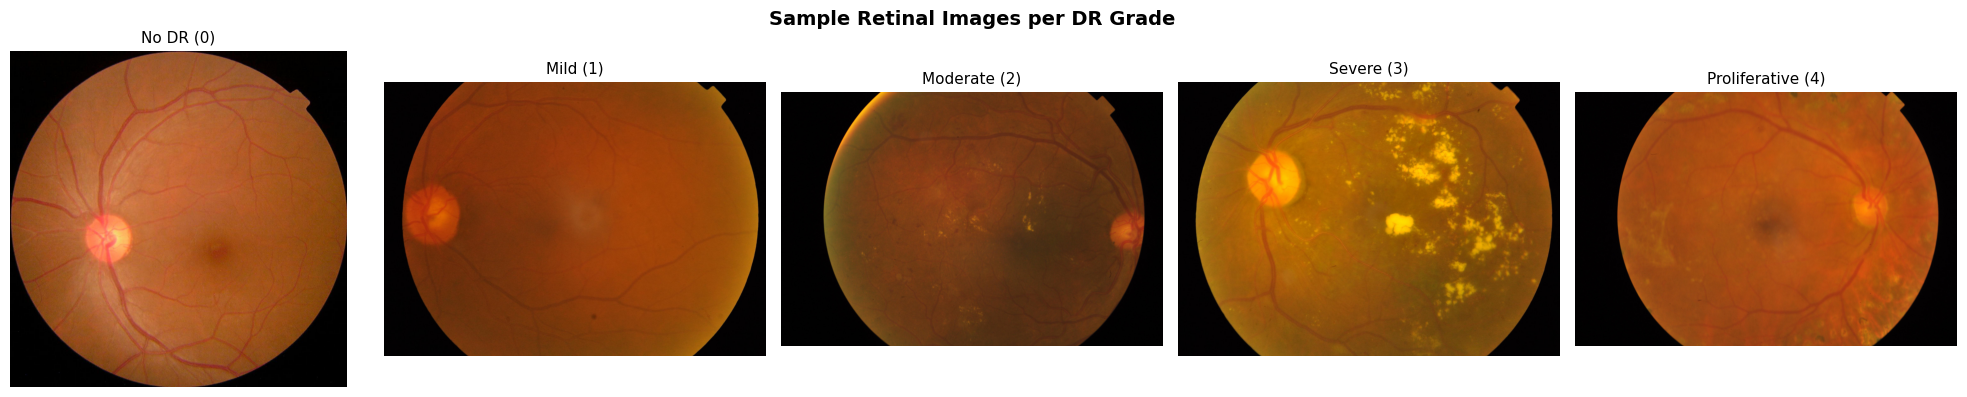

In [4]:
# Display sample retinal images from each class
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
class_names = ['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']

for grade in range(5):
    sample = train_df[train_df['diagnosis'] == grade].iloc[0]
    img_path = f"{DATASET_PATH}/train_images/{sample['id_code']}.png"
    img = Image.open(img_path)
    axes[grade].imshow(img)
    axes[grade].set_title(class_names[grade], fontsize=11)
    axes[grade].axis('off')

plt.suptitle('Sample Retinal Images per DR Grade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Check a few image sizes
for i in range(3):
    img_path = f"{DATASET_PATH}/train_images/{train_df.iloc[i]['id_code']}.png"
    img = Image.open(img_path)
    print(f"Image {i}: {img.size} | Mode: {img.mode}")

Image 0: (3216, 2136) | Mode: RGB
Image 1: (3216, 2136) | Mode: RGB
Image 2: (2416, 1736) | Mode: RGB


In [6]:
# Class weights to handle imbalance
from torch.utils.data import WeightedRandomSampler

# ── Transforms ──────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Dataset Class ────────────────────────────────────────────
class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id  = self.df.loc[idx, 'id_code']
        label   = self.df.loc[idx, 'diagnosis']
        img_path = os.path.join(self.img_dir, f"{img_id}.png")
        image   = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# ── Train / Val Split ────────────────────────────────────────
train_df_split, val_df_split = train_test_split(
    train_df, test_size=0.2, random_state=42,
    stratify=train_df['diagnosis']
)
print(f"Train: {len(train_df_split)} | Val: {len(val_df_split)}")

# ── Datasets ─────────────────────────────────────────────────
IMG_DIR = f"{DATASET_PATH}/train_images"

train_dataset = APTOSDataset(train_df_split, IMG_DIR, transform=train_transforms)
val_dataset   = APTOSDataset(val_df_split,   IMG_DIR, transform=val_transforms)

# ── Weighted Sampler (fixes class imbalance) ─────────────────
class_counts = train_df_split['diagnosis'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_df_split['diagnosis']]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# ── DataLoaders ───────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,   num_workers=2)

print("Datasets & DataLoaders ready ✅")

# Quick sanity check
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape} | Labels: {labels[:8].tolist()}")

Train: 2929 | Val: 733
Datasets & DataLoaders ready ✅
Batch shape: torch.Size([32, 3, 224, 224]) | Labels: [0, 0, 2, 2, 4, 2, 0, 0]


In [10]:
# ── Model ────────────────────────────────────────────────────
class EfficientNetDR(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3):
        super(EfficientNetDR, self).__init__()
        
        # Load pretrained EfficientNet-B0
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        
        # Get the input features of the classifier
        in_features = self.base_model.classifier.in_features
        
        # Replace classifier head with custom one
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.base_model(x)

# ── Initialize ───────────────────────────────────────────────
model = EfficientNetDR(num_classes=5, dropout=0.3).to(device)

# ── Loss & Optimizer ─────────────────────────────────────────
# Class weights for loss function (additional imbalance handling)
class_counts = train_df_split['diagnosis'].value_counts().sort_index().values
weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
weights = weights / weights.sum()  # normalize

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)


# ── Model Summary ─────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"\nModel ready on: {device} ✅")

Total params:     4,336,769
Trainable params: 4,336,769

Model ready on: cuda ✅


In [11]:
# ── Training Loop ─────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    return running_loss / total, correct / total


def val_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return running_loss / total, correct / total, kappa


# ── Train ─────────────────────────────────────────────────────
EPOCHS = 15
best_kappa = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'kappa': []}

print(f"{'Epoch':>5} {'Train Loss':>10} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>10} {'Kappa':>8}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, kappa = val_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['kappa'].append(kappa)
    
    # Save best model
    if kappa > best_kappa:
        best_kappa = kappa
        torch.save(model.state_dict(), 'best_model.pth')
        tag = " ← best"
    else:
        tag = ""
    
    print(f"{epoch:>5} {train_loss:>10.4f} {train_acc:>10.4f} {val_loss:>10.4f} {val_acc:>10.4f} {kappa:>8.4f}{tag}")

print(f"\nBest Quadratic Weighted Kappa: {best_kappa:.4f} ✅")

Epoch Train Loss  Train Acc   Val Loss    Val Acc    Kappa
------------------------------------------------------------
    1     1.2236     0.4032     1.3551     0.5634   0.7768 ← best
    2     0.7988     0.6197     1.1785     0.5894   0.8105 ← best
    3     0.5998     0.6845     1.0245     0.6385   0.7969
    4     0.4808     0.7296     1.0360     0.6808   0.8119 ← best
    5     0.3860     0.7651     1.0611     0.6999   0.8251 ← best
    6     0.3614     0.7887     1.0233     0.7585   0.8567 ← best
    7     0.3073     0.8150     1.0817     0.7544   0.8539
    8     0.2543     0.8433     1.1464     0.7394   0.8386
    9     0.2172     0.8668     1.2027     0.7517   0.8516
   10     0.2212     0.8668     1.1609     0.7681   0.8587 ← best
   11     0.2091     0.8826     1.1112     0.7790   0.8616 ← best
   12     0.1483     0.9078     1.2294     0.7954   0.8696 ← best
   13     0.1523     0.9065     1.2741     0.7858   0.8568
   14     0.1611     0.9123     1.2541     0.7940   0.872

Quadratic Weighted Kappa: 0.8725

Classification Report:
               precision    recall  f1-score   support

        No DR       0.99      0.94      0.96       361
         Mild       0.47      0.64      0.54        74
     Moderate       0.76      0.76      0.76       200
       Severe       0.40      0.46      0.43        39
Proliferative       0.61      0.47      0.53        59

     accuracy                           0.79       733
    macro avg       0.64      0.65      0.64       733
 weighted avg       0.81      0.79      0.80       733



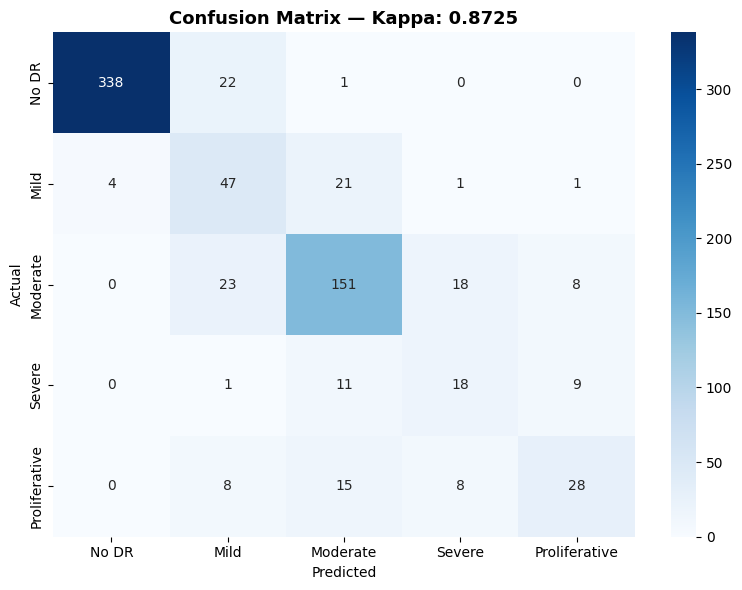

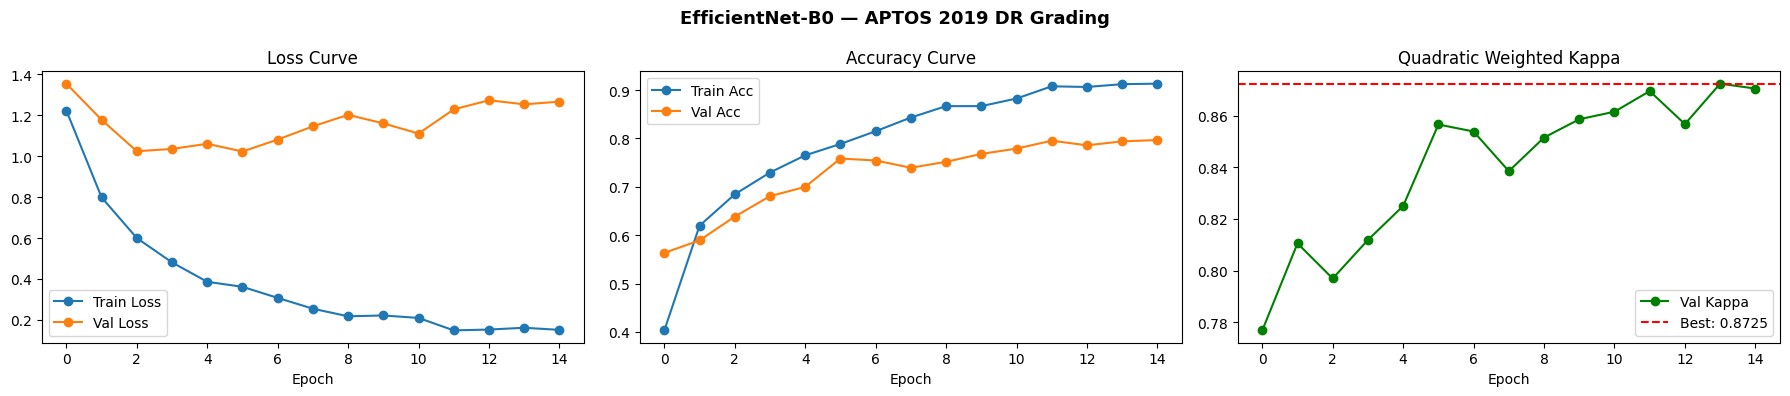

In [13]:
# ── Load Best Model ───────────────────────────────────────────
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# ── Get All Predictions ───────────────────────────────────────
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Metrics ───────────────────────────────────────────────────
kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
print(f"Quadratic Weighted Kappa: {kappa:.4f}")
print(f"\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
))

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'],
            yticklabels=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'])
plt.title(f'Confusion Matrix — Kappa: {kappa:.4f}', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── Training Curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['kappa'], label='Val Kappa', marker='o', color='green')
axes[2].axhline(y=best_kappa, color='red', linestyle='--', label=f'Best: {best_kappa:.4f}')
axes[2].set_title('Quadratic Weighted Kappa')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('EfficientNet-B0 — APTOS 2019 DR Grading', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Actual Grade: 0 — No DR


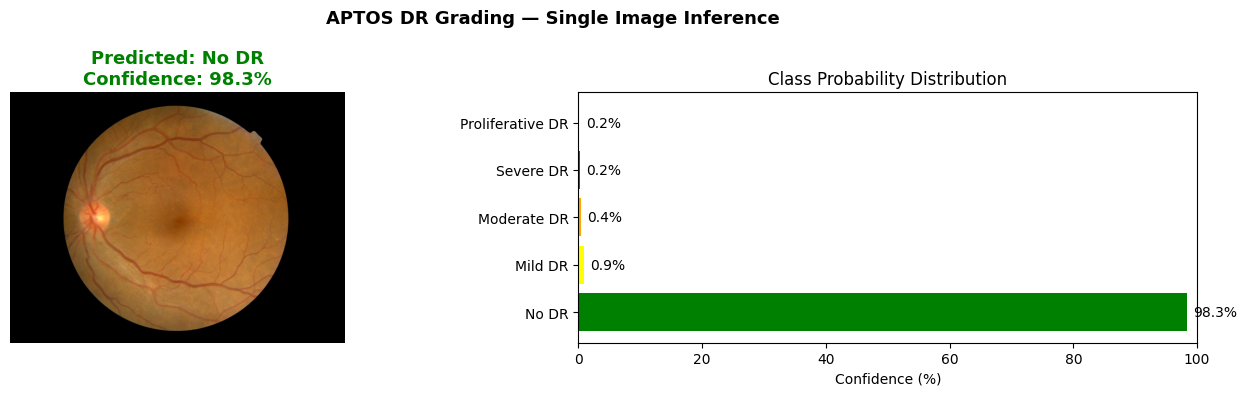

In [14]:
# ── Single Image Inference ────────────────────────────────────
def predict_single(img_path, model, transform):
    model.eval()
    class_names = ['No DR', 'Mild DR', 'Moderate DR', 'Severe DR', 'Proliferative DR']
    colors      = ['green', 'yellow', 'orange', 'red', 'darkred']

    image = Image.open(img_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        pred    = np.argmax(probs)

    # ── Display ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].imshow(image)
    axes[0].set_title(f"Predicted: {class_names[pred]}\nConfidence: {probs[pred]*100:.1f}%",
                      fontsize=13, fontweight='bold', color=colors[pred])
    axes[0].axis('off')

    bars = axes[1].barh(class_names, probs * 100, color=colors)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Class Probability Distribution', fontsize=12)
    axes[1].set_xlim(0, 100)

    for bar, prob in zip(bars, probs):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{prob*100:.1f}%', va='center', fontsize=10)

    plt.suptitle('APTOS DR Grading — Single Image Inference',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return pred, probs


# ── Test on a random val image ────────────────────────────────
sample     = val_df_split.sample(1).iloc[0]
img_path   = f"{DATASET_PATH}/train_images/{sample['id_code']}.png"
actual     = sample['diagnosis']
class_names = ['No DR', 'Mild DR', 'Moderate DR', 'Severe DR', 'Proliferative DR']

print(f"Actual Grade: {actual} — {class_names[actual]}")
pred, probs = predict_single(img_path, model, val_transforms)